# Chapter 25 Python Lab  
## Multivariable Calculus for Data Science and Machine Learning

This lab accompanies **Chapter 25: Multivariable Calculus for Data Science and Machine Learning**.

Data science and machine learning are full of multivariable calculus:

- data points are vectors;
- models are functions of many variables;
- losses are scalar fields on parameter space;
- gradients point toward steepest increase;
- optimization follows negative gradients;
- Hessians describe local curvature;
- Jacobians describe how vector-valued models change;
- regularization changes the geometry of loss landscapes;
- PCA uses quadratic forms and variance maximization;
- neural networks are compositions of functions, so training uses the chain rule.

This lab uses `numpy` and `matplotlib` to build a computational bridge between multivariable calculus and modern machine learning.

We will explore:

- feature spaces and loss landscapes;
- linear regression as multivariable optimization;
- gradient descent and Newton's method;
- regularization and ridge regression;
- logistic regression and cross-entropy;
- softmax classification;
- Jacobians in feature maps;
- PCA as variance optimization;
- K-means as coordinate descent;
- a small neural network trained by backpropagation;
- and a mini-project on an end-to-end supervised learning workflow.

## Learning goals

By the end of this lab, you should be able to:

1. represent data as vectors and matrices;
2. interpret losses as scalar functions of parameters;
3. compute and visualize gradients of loss functions;
4. implement gradient descent and compare step sizes;
5. use Hessians to understand curvature and Newton steps;
6. solve least-squares and ridge-regression problems;
7. optimize logistic regression using gradients;
8. understand softmax and multiclass cross-entropy;
9. compute Jacobians for feature maps and model maps;
10. connect PCA with covariance matrices and quadratic forms;
11. implement K-means as an alternating minimization method;
12. train a tiny neural network using the chain rule.

## Source note

This notebook was generated from the uploaded Chapter 25 QMD file.  
The extracted early headings from the source file include:

- Learning goals
- 25.1 Why machine learning is multivariable calculus
- Main principle
- 25.2 A first loss function: least squares
- Worked example: gradient of the least-squares loss
- 25.3 Matrix form and the geometry of linear models
- Geometry of least squares
- Worked example: gradient descent for linear regression
- 25.4 Empirical risk and the structure of training problems
- 25.5 Logistic regression and classification
- 25.6 Regularization and the bias--variance tradeoff
- Calculus interpretation of regularization
- 25.7 Stochastic gradient descent
- Reuse linear regression data X and y_vec.
- 25.8 Neural networks and the chain rule
- A scalar example

## 0. Setup

Run this cell first.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)
norm = np.linalg.norm

def sigmoid(z):
    return 1/(1 + np.exp(-z))

def softmax(Z, axis=1):
    Z = Z - np.max(Z, axis=axis, keepdims=True)
    E = np.exp(Z)
    return E/np.sum(E, axis=axis, keepdims=True)

def train_test_split(X, y, test_fraction=0.25, seed=0):
    rng = np.random.default_rng(seed)
    n = len(X)
    idx = rng.permutation(n)
    n_test = int(round(test_fraction*n))
    test_idx = idx[:n_test]
    train_idx = idx[n_test:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

def standardize_train_test(X_train, X_test):
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)
    std = np.where(std < 1e-12, 1.0, std)
    return (X_train-mean)/std, (X_test-mean)/std, mean, std

def add_intercept(X):
    return np.column_stack([np.ones(len(X)), X])

def mse(y_true, y_pred):
    return float(np.mean((y_true-y_pred)**2))

def accuracy(y_true, y_pred):
    return float(np.mean(y_true == y_pred))

def finite_gradient(f, p, h=1e-5):
    p = np.asarray(p, dtype=float)
    g = np.zeros_like(p)
    for j in range(len(p)):
        step = np.zeros_like(p)
        step[j] = h
        g[j] = (f(p + step) - f(p - step))/(2*h)
    return g

def finite_hessian(f, p, h=1e-4):
    p = np.asarray(p, dtype=float)
    n = len(p)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            ei = np.zeros(n); ej = np.zeros(n)
            ei[i] = h; ej[j] = h
            H[i] = H[i]
            H[i,j] = (f(p+ei+ej) - f(p+ei-ej) - f(p-ei+ej) + f(p-ei-ej))/(4*h*h)
    return H

def gradient_descent(f, grad, start, step_size=0.05, steps=200):
    theta = np.asarray(start, dtype=float)
    path = [theta.copy()]
    values = [f(theta)]
    for k in range(steps):
        theta = theta - step_size*grad(theta)
        path.append(theta.copy())
        values.append(f(theta))
    return np.array(path), np.array(values)

def newton_method(f, grad, hess, start, steps=10, damping=1.0):
    theta = np.asarray(start, dtype=float)
    path = [theta.copy()]
    values = [f(theta)]
    for k in range(steps):
        H = hess(theta)
        g = grad(theta)
        step = np.linalg.solve(H, g)
        theta = theta - damping*step
        path.append(theta.copy())
        values.append(f(theta))
    return np.array(path), np.array(values)

def contour_loss_2d(loss, center, radius0=4, radius1=4, n=220, title="Loss contours"):
    b0 = np.linspace(center[0]-radius0, center[0]+radius0, n)
    b1 = np.linspace(center[1]-radius1, center[1]+radius1, n)
    B0, B1 = np.meshgrid(b0, b1)
    Z = np.zeros_like(B0)
    for i in range(n):
        for j in range(n):
            Z[i,j] = loss(np.array([B0[i,j], B1[i,j]]))
    plt.figure(figsize=(7, 6))
    cs = plt.contour(B0, B1, Z, levels=28)
    plt.clabel(cs, inline=True, fontsize=8)
    plt.xlabel(r"$\theta_0$")
    plt.ylabel(r"$\theta_1$")
    plt.title(title)
    plt.grid(True, alpha=0.25)
    return B0, B1, Z

def plot_path_on_contours(B0, B1, Z, paths, labels, title="Optimization paths"):
    plt.figure(figsize=(7, 6))
    cs = plt.contour(B0, B1, Z, levels=28)
    plt.clabel(cs, inline=True, fontsize=8)
    for path, label in zip(paths, labels):
        plt.plot(path[:,0], path[:,1], marker="o", markersize=3, linewidth=2, label=label)
    plt.xlabel(r"$\theta_0$")
    plt.ylabel(r"$\theta_1$")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.show()

def covariance_ellipse_points(mu, Sigma, level=1.0, n=400):
    theta = np.linspace(0, 2*np.pi, n)
    circle = np.vstack([np.cos(theta), np.sin(theta)])
    eigvals, eigvecs = np.linalg.eigh(Sigma)
    A = eigvecs @ np.diag(np.sqrt(np.maximum(eigvals, 0)))
    pts = np.asarray(mu)[:,None] + level*(A @ circle)
    return pts[0], pts[1]

def one_hot(y, K):
    Y = np.zeros((len(y), K))
    Y[np.arange(len(y)), y] = 1
    return Y

print("Setup complete.")

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-xxe9r4qd because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Setup complete.


---

# Part I. Data as points in feature space

A data set with $n$ observations and $p$ features is often represented as a matrix

$$
X\in\mathbb R^{n\times p}.
$$

Each row is a data point:

$$
x_i=(x_{i1},x_{i2},\ldots,x_{ip}).
$$

A model usually maps a feature vector to a prediction:

$$
f_\theta(x_i)\approx y_i.
$$

The parameter vector $\theta$ lives in parameter space.  
Training means minimizing a loss function over parameter space.

## 1. Simulate a two-feature regression data set

X_raw shape: (160, 2)
X_design shape: (160, 3)
y shape: (160,)
First five rows of X_design:
[[ 1.        0.35404  -0.004965]
 [ 1.       -0.531598 -2.276566]
 [ 1.        0.018715  0.927369]
 [ 1.        1.043335 -0.536198]
 [ 1.        2.229364  1.943692]]
True theta: [ 1.2  2.  -1.4]


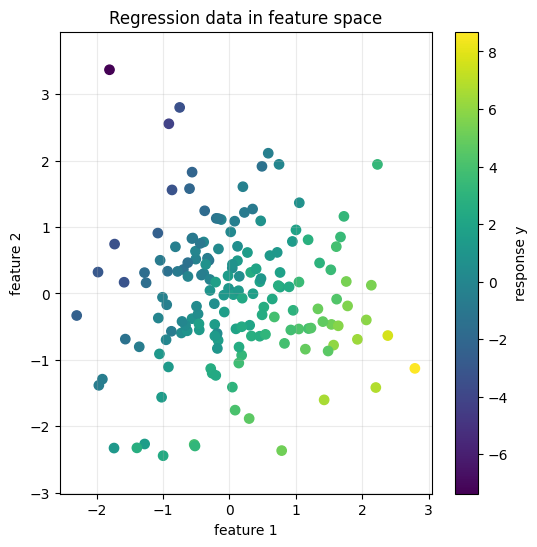

In [2]:
rng = np.random.default_rng(25)

n = 160
X_raw = rng.normal(size=(n, 2))
true_theta = np.array([1.2, 2.0, -1.4])  # intercept, coefficients
noise = rng.normal(scale=0.45, size=n)
X_design = add_intercept(X_raw)
y = X_design @ true_theta + noise

print("X_raw shape:", X_raw.shape)
print("X_design shape:", X_design.shape)
print("y shape:", y.shape)
print("First five rows of X_design:")
print(X_design[:5])
print("True theta:", true_theta)

plt.figure(figsize=(6, 6))
sc = plt.scatter(X_raw[:,0], X_raw[:,1], c=y, s=45)
plt.colorbar(sc, label="response y")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.title("Regression data in feature space")
plt.axis("equal")
plt.grid(True, alpha=0.25)
plt.show()

---

# Part II. Linear regression as a loss landscape

For linear regression,

$$
\widehat y=X\theta.
$$

The mean squared error loss is

$$
L(\theta)=\frac{1}{2n}\|X\theta-y\|^2.
$$

This is a scalar function of the parameter vector $\theta$.  
Its gradient is

$$
\nabla L(\theta)=\frac1nX^T(X\theta-y),
$$

and its Hessian is

$$
H=\frac1nX^TX.
$$

So the loss is an exact quadratic.

## 2. Loss, gradient, and Hessian for least squares

In [3]:
def lin_loss(theta):
    theta = np.asarray(theta, dtype=float)
    r = X_design @ theta - y
    return float(0.5*np.mean(r**2))

def lin_grad(theta):
    theta = np.asarray(theta, dtype=float)
    r = X_design @ theta - y
    return X_design.T @ r / len(y)

def lin_hess(theta):
    return X_design.T @ X_design / len(y)

theta_lstsq = np.linalg.lstsq(X_design, y, rcond=None)[0]
H_lin = lin_hess(theta_lstsq)

print("Least-squares estimate:", theta_lstsq)
print("True theta:", true_theta)
print("Gradient at estimate:", lin_grad(theta_lstsq))
print("Hessian:")
print(H_lin)
print("Hessian eigenvalues:", np.linalg.eigvalsh(H_lin))
print("Loss at estimate:", lin_loss(theta_lstsq))

Least-squares estimate: [ 1.204936  2.019457 -1.418413]
True theta: [ 1.2  2.  -1.4]
Gradient at estimate: [ 0.  0. -0.]
Hessian:
[[ 1.        0.069552 -0.016686]
 [ 0.069552  0.991386  0.025373]
 [-0.016686  0.025373  1.019818]]
Hessian eigenvalues: [0.917265 1.027876 1.066062]
Loss at estimate: 0.11522764636458956


## 3. Gradient descent for least squares

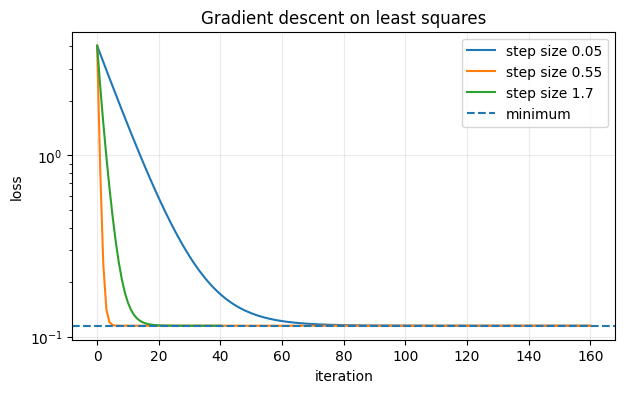

Final theta, step 0.05: [ 1.204987  2.018865 -1.417995]
Final theta, step 0.55: [ 1.204936  2.019457 -1.418413]
Final theta, step 1.7: [ 1.204575  2.019104 -1.418467]


In [4]:
start = np.zeros(3)

path_small, values_small = gradient_descent(lin_loss, lin_grad, start, step_size=0.05, steps=160)
path_good, values_good = gradient_descent(lin_loss, lin_grad, start, step_size=0.55, steps=160)
path_large, values_large = gradient_descent(lin_loss, lin_grad, start, step_size=1.7, steps=40)

plt.figure(figsize=(7, 4))
plt.plot(values_small, label="step size 0.05")
plt.plot(values_good, label="step size 0.55")
plt.plot(values_large, label="step size 1.7")
plt.axhline(lin_loss(theta_lstsq), linestyle="--", label="minimum")
plt.yscale("log")
plt.xlabel("iteration")
plt.ylabel("loss")
plt.title("Gradient descent on least squares")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

print("Final theta, step 0.05:", path_small[-1])
print("Final theta, step 0.55:", path_good[-1])
print("Final theta, step 1.7:", path_large[-1])

## 4. Step size and Hessian eigenvalues

For a quadratic loss with Hessian $H$, gradient descent is stable when the step size is roughly below

$$
\frac{2}{\lambda_{\max}(H)}.
$$

This is why curvature matters for optimization.

In [5]:
eigvals = np.linalg.eigvalsh(H_lin)
lambda_max = eigvals[-1]
stable_bound = 2/lambda_max

print("Hessian eigenvalues:", eigvals)
print("Largest eigenvalue:", lambda_max)
print("Approximate stability bound 2/lambda_max:", stable_bound)

Hessian eigenvalues: [0.917265 1.027876 1.066062]
Largest eigenvalue: 1.0660624551658224
Approximate stability bound 2/lambda_max: 1.8760626924891626


## 5. Newton's method reaches the minimum in one step for a quadratic

For an exact quadratic loss,

$$
\theta_{\text{new}}=\theta-H^{-1}\nabla L(\theta)
$$

jumps directly to the minimizer.

In [6]:
path_newton, values_newton = newton_method(
    lin_loss,
    lin_grad,
    lin_hess,
    start,
    steps=3
)

print("Newton path:")
print(path_newton)
print("Newton values:", values_newton)
print("Least-squares estimate:", theta_lstsq)

Newton path:
[[ 0.        0.        0.      ]
 [ 1.204936  2.019457 -1.418413]
 [ 1.204936  2.019457 -1.418413]
 [ 1.204936  2.019457 -1.418413]]
Newton values: [4.013667 0.115228 0.115228 0.115228]
Least-squares estimate: [ 1.204936  2.019457 -1.418413]


---

# Part III. Visualizing a two-parameter loss landscape

To visualize a loss, we restrict to simple linear regression with one feature:

$$
\widehat y_i=\theta_0+\theta_1x_i.
$$

Then $L(\theta_0,\theta_1)$ is a surface over a two-dimensional parameter plane.

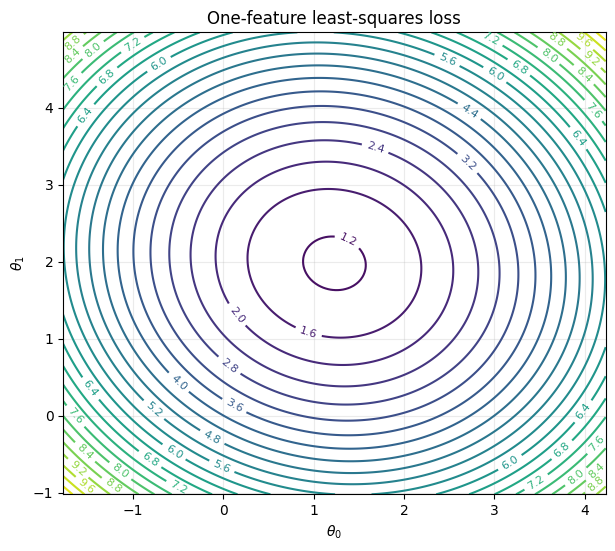

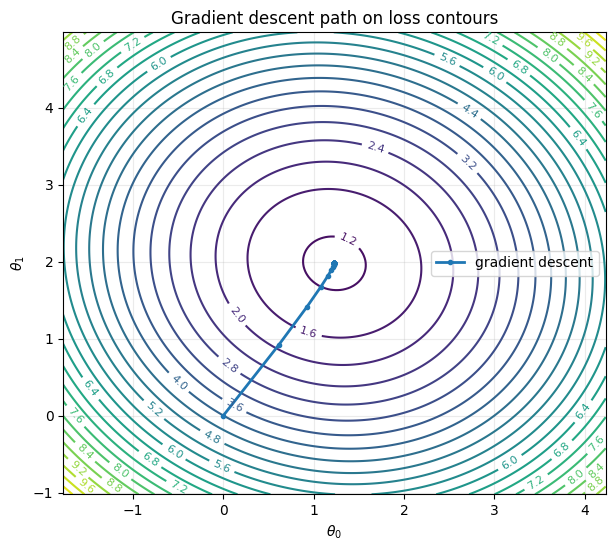

One-feature least-squares estimate: [1.231257 1.981308]


In [7]:
x1 = X_raw[:,0]
X_one = add_intercept(x1.reshape(-1, 1))
y_one = y.copy()

def loss_one(theta):
    theta = np.asarray(theta, dtype=float)
    r = X_one @ theta - y_one
    return float(0.5*np.mean(r**2))

def grad_one(theta):
    theta = np.asarray(theta, dtype=float)
    r = X_one @ theta - y_one
    return X_one.T @ r / len(y_one)

def hess_one(theta):
    return X_one.T @ X_one / len(y_one)

theta_one_hat = np.linalg.lstsq(X_one, y_one, rcond=None)[0]

B0, B1, Zloss = contour_loss_2d(
    loss_one,
    theta_one_hat,
    radius0=3,
    radius1=3,
    n=220,
    title="One-feature least-squares loss"
)

path_one, values_one = gradient_descent(loss_one, grad_one, np.array([0.0, 0.0]), step_size=0.45, steps=40)

plot_path_on_contours(
    B0, B1, Zloss,
    [path_one],
    ["gradient descent"],
    title="Gradient descent path on loss contours"
)

print("One-feature least-squares estimate:", theta_one_hat)

---

# Part IV. Feature scaling and conditioning

Gradient descent can be slow when the loss contours are long and narrow.  
This happens when features have very different scales.

The Hessian

$$
H=\frac1nX^TX
$$

reveals the geometry. A large condition number means high anisotropy.

## 6. Badly scaled features

In [8]:
rng = np.random.default_rng(251)

n = 180
x_small = rng.normal(scale=1.0, size=n)
x_large = rng.normal(scale=25.0, size=n)
X_bad_raw = np.column_stack([x_small, x_large])
X_bad = add_intercept(X_bad_raw)
theta_bad_true = np.array([0.5, 1.0, -0.08])
y_bad = X_bad @ theta_bad_true + rng.normal(scale=0.7, size=n)

def make_ls_functions(Xmat, yvec):
    def loss(theta):
        r = Xmat @ theta - yvec
        return float(0.5*np.mean(r**2))
    def grad(theta):
        r = Xmat @ theta - yvec
        return Xmat.T @ r / len(yvec)
    def hess(theta):
        return Xmat.T @ Xmat / len(yvec)
    return loss, grad, hess

loss_bad, grad_bad, hess_bad = make_ls_functions(X_bad, y_bad)
theta_bad_hat = np.linalg.lstsq(X_bad, y_bad, rcond=None)[0]
H_bad = hess_bad(theta_bad_hat)

condition_bad = np.linalg.cond(H_bad)

print("Unscaled Hessian eigenvalues:", np.linalg.eigvalsh(H_bad))
print("Unscaled condition number:", condition_bad)
print("Unscaled theta estimate:", theta_bad_hat)

Unscaled Hessian eigenvalues: [  0.954167   1.086329 538.539832]
Unscaled condition number: 564.4085841529359
Unscaled theta estimate: [ 0.51745   0.936341 -0.080726]


Scaled Hessian eigenvalues: [0.86576 1.      1.13424]
Scaled condition number: 1.3101085438580535
Scaled theta estimate: [ 0.498635  0.962737 -1.87194 ]


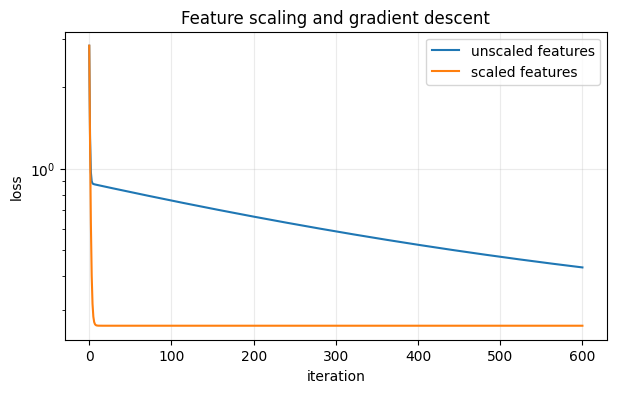

In [9]:
X_bad_scaled_features, _, mean_bad, std_bad = standardize_train_test(X_bad_raw, X_bad_raw)
X_good = add_intercept(X_bad_scaled_features)

loss_scaled, grad_scaled, hess_scaled = make_ls_functions(X_good, y_bad)
theta_scaled_hat = np.linalg.lstsq(X_good, y_bad, rcond=None)[0]
H_scaled = hess_scaled(theta_scaled_hat)

print("Scaled Hessian eigenvalues:", np.linalg.eigvalsh(H_scaled))
print("Scaled condition number:", np.linalg.cond(H_scaled))
print("Scaled theta estimate:", theta_scaled_hat)

path_unscaled, vals_unscaled = gradient_descent(loss_bad, grad_bad, np.zeros(3), step_size=0.001, steps=600)
path_scaled, vals_scaled = gradient_descent(loss_scaled, grad_scaled, np.zeros(3), step_size=0.35, steps=600)

plt.figure(figsize=(7, 4))
plt.plot(vals_unscaled, label="unscaled features")
plt.plot(vals_scaled, label="scaled features")
plt.yscale("log")
plt.xlabel("iteration")
plt.ylabel("loss")
plt.title("Feature scaling and gradient descent")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

---

# Part V. Regularization and ridge regression

Regularization adds a penalty to the loss:

$$
L_\lambda(\theta)=\frac{1}{2n}\|X\theta-y\|^2+\frac{\lambda}{2}\|\theta_{1:p}\|^2.
$$

Usually the intercept is not penalized.

The gradient becomes

$$
\nabla L_\lambda(\theta)=\frac1nX^T(X\theta-y)+\lambda\begin{bmatrix}0\\\theta_1\\\vdots\\\theta_p\end{bmatrix}.
$$

The Hessian becomes

$$
H_\lambda=\frac1nX^TX+\lambda D,
$$

where $D$ penalizes non-intercept coordinates.

## 7. Ridge regression path

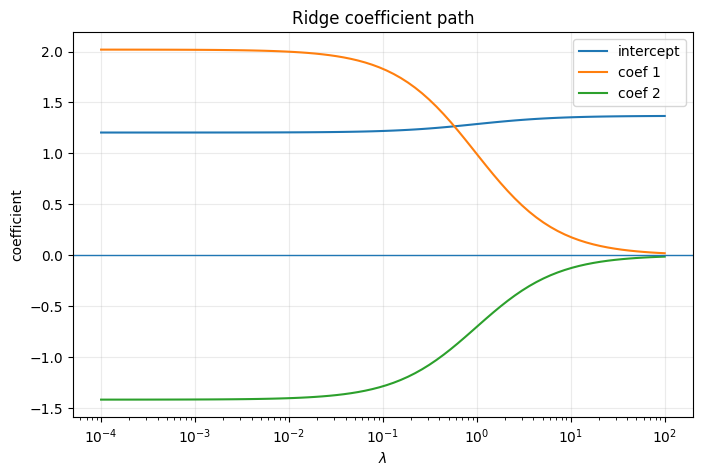

Least-squares coefficients: [ 1.204936  2.019457 -1.418413]
Ridge coefficients at lambda=1: [ 1.28825   0.99333  -0.702587]


In [10]:
def ridge_solution(Xmat, yvec, lam):
    p = Xmat.shape[1]
    D = np.eye(p)
    D[0,0] = 0
    A = Xmat.T @ Xmat / len(yvec) + lam*D
    b = Xmat.T @ yvec / len(yvec)
    return np.linalg.solve(A, b)

lambdas = np.logspace(-4, 2, 80)
coefs = np.array([ridge_solution(X_design, y, lam) for lam in lambdas])

plt.figure(figsize=(8, 5))
for j in range(coefs.shape[1]):
    label = "intercept" if j == 0 else f"coef {j}"
    plt.semilogx(lambdas, coefs[:,j], label=label)
plt.axhline(0, linewidth=1)
plt.xlabel(r"$\lambda$")
plt.ylabel("coefficient")
plt.title("Ridge coefficient path")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

print("Least-squares coefficients:", theta_lstsq)
print("Ridge coefficients at lambda=1:", ridge_solution(X_design, y, 1.0))

## 8. Regularization changes curvature

The ridge Hessian has larger eigenvalues in penalized directions.  
This improves conditioning and shrinks coefficients.

In [11]:
def ridge_hessian(Xmat, lam):
    p = Xmat.shape[1]
    D = np.eye(p)
    D[0,0] = 0
    return Xmat.T @ Xmat / Xmat.shape[0] + lam*D

for lam in [0, 0.01, 0.1, 1, 10]:
    H = ridge_hessian(X_design, lam)
    print(f"lambda={lam:5.2f}, eigenvalues={np.linalg.eigvalsh(H)}, condition={np.linalg.cond(H):.3f}")

lambda= 0.00, eigenvalues=[0.917265 1.027876 1.066062], condition=1.162
lambda= 0.01, eigenvalues=[0.922864 1.036968 1.071371], condition=1.161
lambda= 0.10, eigenvalues=[0.958024 1.112183 1.140997], condition=1.191
lambda= 1.00, eigenvalues=[0.994813 1.981253 2.035137], condition=2.046
lambda=10.00, eigenvalues=[ 0.999487 10.976987 11.034729], condition=11.040


---

# Part VI. Logistic regression and cross-entropy

For binary classification,

$$
p_i=P(Y_i=1\mid x_i)=\sigma(x_i^T\beta),
$$

where

$$
\sigma(z)=\frac1{1+e^{-z}}.
$$

The negative log-likelihood, also called cross-entropy loss, is

$$
L(\beta)=\frac1n\sum_i
\left[
\log(1+e^{x_i^T\beta})-y_i x_i^T\beta
\right].
$$

Its gradient is

$$
\nabla L(\beta)=\frac1nX^T(p-y),
$$

and its Hessian is

$$
H=\frac1nX^T W X,
$$

where $W=\operatorname{diag}(p_i(1-p_i))$.

## 9. Simulate binary classification data

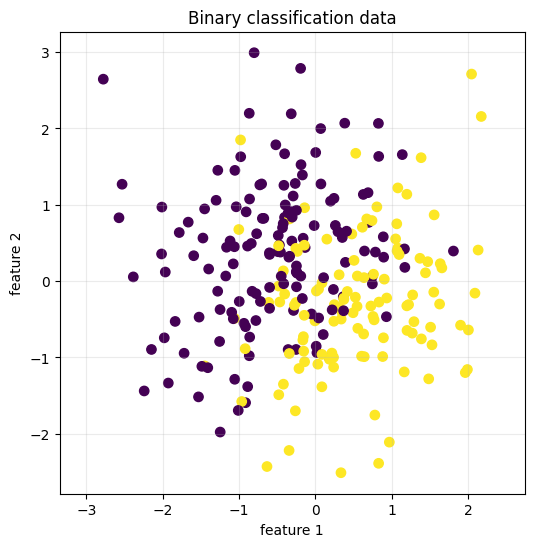

Class proportion: 0.4461538461538462


In [12]:
rng = np.random.default_rng(252)

n = 260
X_class_raw = rng.normal(size=(n, 2))
beta_true = np.array([-0.2, 2.0, -1.5])
X_class = add_intercept(X_class_raw)
p_true = sigmoid(X_class @ beta_true)
y_class = rng.binomial(1, p_true)

plt.figure(figsize=(6, 6))
plt.scatter(X_class_raw[:,0], X_class_raw[:,1], c=y_class, s=45)
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.title("Binary classification data")
plt.axis("equal")
plt.grid(True, alpha=0.25)
plt.show()

print("Class proportion:", y_class.mean())

## 10. Logistic loss, gradient, Hessian, and Newton method

True beta: [-0.2  2.  -1.5]
Estimated beta: [-0.222337  1.904981 -1.177957]
Final gradient: [-0. -0. -0.]
Training accuracy: 0.8115384615384615
Hessian eigenvalues at estimate: [0.049754 0.137672 0.141075]


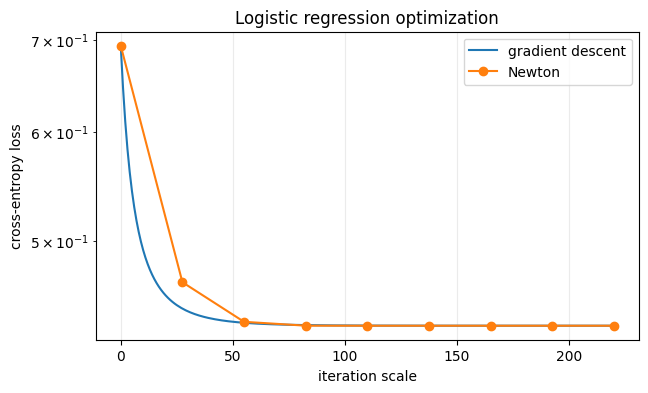

In [13]:
def log_loss(beta):
    beta = np.asarray(beta, dtype=float)
    eta = X_class @ beta
    return float(np.mean(np.logaddexp(0, eta) - y_class*eta))

def log_grad(beta):
    beta = np.asarray(beta, dtype=float)
    p = sigmoid(X_class @ beta)
    return X_class.T @ (p - y_class) / len(y_class)

def log_hess(beta):
    beta = np.asarray(beta, dtype=float)
    p = sigmoid(X_class @ beta)
    w = p*(1-p)
    return X_class.T @ (X_class*w[:,None]) / len(y_class)

beta0 = np.zeros(3)
path_log_gd, vals_log_gd = gradient_descent(log_loss, log_grad, beta0, step_size=0.5, steps=220)
path_log_nt, vals_log_nt = newton_method(log_loss, log_grad, log_hess, beta0, steps=8, damping=1.0)

beta_log_hat = path_log_nt[-1]
p_hat = sigmoid(X_class @ beta_log_hat)
y_pred = (p_hat >= 0.5).astype(int)

print("True beta:", beta_true)
print("Estimated beta:", beta_log_hat)
print("Final gradient:", log_grad(beta_log_hat))
print("Training accuracy:", accuracy(y_class, y_pred))
print("Hessian eigenvalues at estimate:", np.linalg.eigvalsh(log_hess(beta_log_hat)))

plt.figure(figsize=(7, 4))
plt.plot(vals_log_gd, label="gradient descent")
plt.plot(np.linspace(0, len(vals_log_gd)-1, len(vals_log_nt)), vals_log_nt, marker="o", label="Newton")
plt.yscale("log")
plt.xlabel("iteration scale")
plt.ylabel("cross-entropy loss")
plt.title("Logistic regression optimization")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

## 11. Decision boundary

The decision boundary is

$$
\beta_0+\beta_1x_1+\beta_2x_2=0.
$$

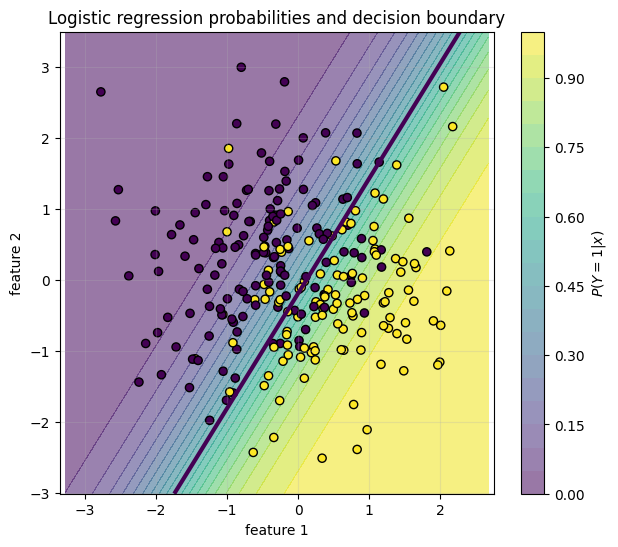

In [14]:
x_min, x_max = X_class_raw[:,0].min()-0.5, X_class_raw[:,0].max()+0.5
y_min, y_max = X_class_raw[:,1].min()-0.5, X_class_raw[:,1].max()+0.5
xx = np.linspace(x_min, x_max, 300)
yy = np.linspace(y_min, y_max, 300)
XX, YY = np.meshgrid(xx, yy)
ZZ = sigmoid(beta_log_hat[0] + beta_log_hat[1]*XX + beta_log_hat[2]*YY)

plt.figure(figsize=(7, 6))
plt.contourf(XX, YY, ZZ, levels=20, alpha=0.55)
plt.colorbar(label=r"$P(Y=1|x)$")
plt.contour(XX, YY, ZZ, levels=[0.5], linewidths=3)
plt.scatter(X_class_raw[:,0], X_class_raw[:,1], c=y_class, s=35, edgecolor="k")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.title("Logistic regression probabilities and decision boundary")
plt.axis("equal")
plt.grid(True, alpha=0.25)
plt.show()

---

# Part VII. Softmax classification

For $K$ classes, softmax regression computes scores

$$
S=XW,
$$

then probabilities

$$
P_{ik}=\frac{e^{S_{ik}}}{\sum_{\ell=1}^K e^{S_{i\ell}}}.
$$

The cross-entropy loss is

$$
L(W)=
-\frac1n\sum_i\log P_{i,y_i}.
$$

The gradient is

$$
\nabla_W L=\frac1n X^T(P-Y),
$$

where $Y$ is the one-hot class matrix.

## 12. Three-class softmax example

Training accuracy: 0.9851851851851852
Final softmax loss: 0.03768286230057433


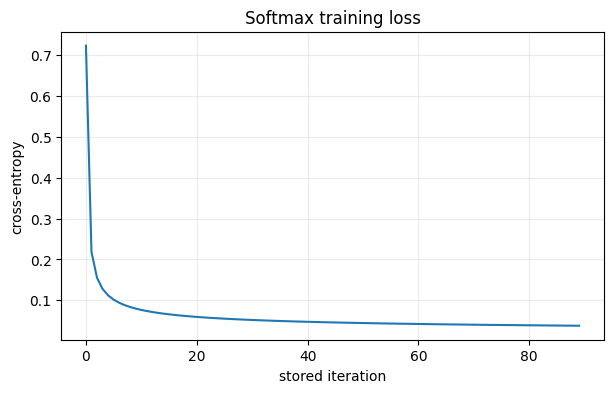

In [15]:
rng = np.random.default_rng(253)

n_per = 90
means = np.array([[-2, 0], [2, 0], [0, 2.5]])
X_multi_raw = np.vstack([
    rng.normal(loc=means[k], scale=0.75, size=(n_per, 2))
    for k in range(3)
])
y_multi = np.repeat(np.arange(3), n_per)
X_multi = add_intercept(X_multi_raw)
Y_multi = one_hot(y_multi, 3)

def softmax_loss(W_flat):
    W = W_flat.reshape(X_multi.shape[1], 3)
    S = X_multi @ W
    P = softmax(S, axis=1)
    return float(-np.mean(np.sum(Y_multi*np.log(P + 1e-12), axis=1)))

def softmax_grad(W_flat):
    W = W_flat.reshape(X_multi.shape[1], 3)
    S = X_multi @ W
    P = softmax(S, axis=1)
    G = X_multi.T @ (P - Y_multi) / len(y_multi)
    return G.ravel()

W = np.zeros((X_multi.shape[1], 3)).ravel()
path_losses = []
for k in range(900):
    W = W - 0.35*softmax_grad(W)
    if k % 10 == 0:
        path_losses.append(softmax_loss(W))

W_hat = W.reshape(X_multi.shape[1], 3)
P_hat = softmax(X_multi @ W_hat, axis=1)
y_hat = np.argmax(P_hat, axis=1)

print("Training accuracy:", accuracy(y_multi, y_hat))
print("Final softmax loss:", softmax_loss(W.ravel()))

plt.figure(figsize=(7, 4))
plt.plot(path_losses)
plt.xlabel("stored iteration")
plt.ylabel("cross-entropy")
plt.title("Softmax training loss")
plt.grid(True, alpha=0.25)
plt.show()

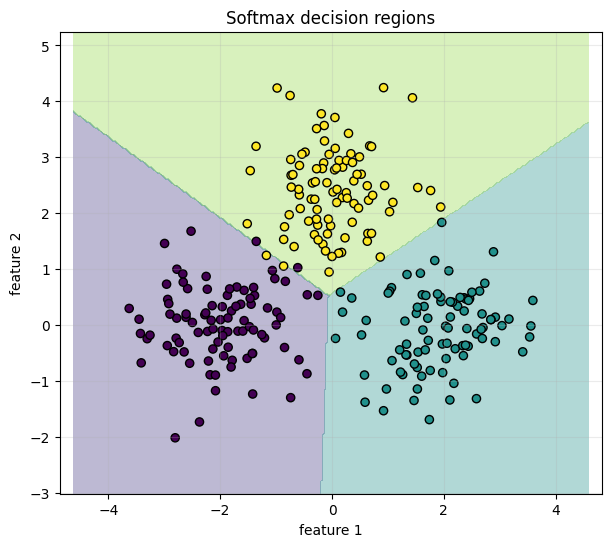

In [16]:
x_min, x_max = X_multi_raw[:,0].min()-1, X_multi_raw[:,0].max()+1
y_min, y_max = X_multi_raw[:,1].min()-1, X_multi_raw[:,1].max()+1
xx = np.linspace(x_min, x_max, 300)
yy = np.linspace(y_min, y_max, 300)
XX, YY = np.meshgrid(xx, yy)
Grid = add_intercept(np.column_stack([XX.ravel(), YY.ravel()]))
Probs = softmax(Grid @ W_hat, axis=1)
Pred = np.argmax(Probs, axis=1).reshape(XX.shape)

plt.figure(figsize=(7, 6))
plt.contourf(XX, YY, Pred, levels=[-0.5,0.5,1.5,2.5], alpha=0.35)
plt.scatter(X_multi_raw[:,0], X_multi_raw[:,1], c=y_multi, s=35, edgecolor="k")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.title("Softmax decision regions")
plt.axis("equal")
plt.grid(True, alpha=0.25)
plt.show()

---

# Part VIII. Jacobians and feature maps

Machine learning often transforms data through feature maps:

$$
\phi:\mathbb R^p\to\mathbb R^q.
$$

The Jacobian

$$
J_\phi(x)
$$

describes local stretching, sensitivity, and how gradients move through transformations.

For example, the polar-inspired feature map

$$
\phi(x,y)=
\begin{bmatrix}
x\\
y\\
x^2+y^2\\
\sin x
\end{bmatrix}
$$

has a $4\times2$ Jacobian.

## 13. Numerical Jacobian of a feature map

In [17]:
def feature_map(p):
    x, y0 = p
    return np.array([x, y0, x**2 + y0**2, np.sin(x)])

def finite_jacobian(phi, p, h=1e-5):
    p = np.asarray(p, dtype=float)
    out0 = phi(p)
    J = np.zeros((len(out0), len(p)))
    for j in range(len(p)):
        step = np.zeros_like(p)
        step[j] = h
        J[:,j] = (phi(p+step) - phi(p-step))/(2*h)
    return J

p0 = np.array([1.2, -0.7])
J_num = finite_jacobian(feature_map, p0)

J_exact = np.array([
    [1, 0],
    [0, 1],
    [2*p0[0], 2*p0[1]],
    [np.cos(p0[0]), 0]
])

print("Numerical Jacobian:")
print(J_num)
print("Exact Jacobian:")
print(J_exact)
print("Difference:")
print(J_num - J_exact)

Numerical Jacobian:
[[ 1.        0.      ]
 [ 0.        1.      ]
 [ 2.4      -1.4     ]
 [ 0.362358  0.      ]]
Exact Jacobian:
[[ 1.        0.      ]
 [ 0.        1.      ]
 [ 2.4      -1.4     ]
 [ 0.362358  0.      ]]
Difference:
[[ 0.  0.]
 [ 0. -0.]
 [ 0.  0.]
 [-0.  0.]]


## 14. Gradient through a feature map

If

$$
L(x)=g(\phi(x)),
$$

then the chain rule says

$$
\nabla_x L=J_\phi(x)^T\nabla_z g.
$$

In [18]:
# Let g(z)=1/2 ||z-a||^2.
a_vec = np.array([0.5, -1.0, 2.0, 0.2])

def L_composed(p):
    z = feature_map(p)
    return 0.5*np.sum((z-a_vec)**2)

grad_numeric = finite_gradient(L_composed, p0)
z0 = feature_map(p0)
grad_g = z0 - a_vec
grad_chain = J_exact.T @ grad_g

print("Numerical gradient of L:", grad_numeric)
print("Chain-rule gradient:", grad_chain)
print("Difference:", grad_numeric - grad_chain)

Numerical gradient of L: [0.79726 0.398  ]
Chain-rule gradient: [0.79726 0.398  ]
Difference: [ 0. -0.]


---

# Part IX. PCA as variance maximization

Principal component analysis finds directions of maximum variance.

For centered data matrix $X$, the covariance matrix is

$$
C=\frac1nX^TX.
$$

The variance in a unit direction $u$ is

$$
u^TCu.
$$

Maximizing $u^TCu$ subject to $\|u\|=1$ gives the top eigenvector of $C$.

## 15. PCA geometry

Sample covariance:
[[3.080143 1.803932]
 [1.803932 1.473595]]
Eigenvalues: [4.251564 0.302173]
Principal directions as columns:
[[-0.838685  0.544617]
 [-0.544617 -0.838685]]


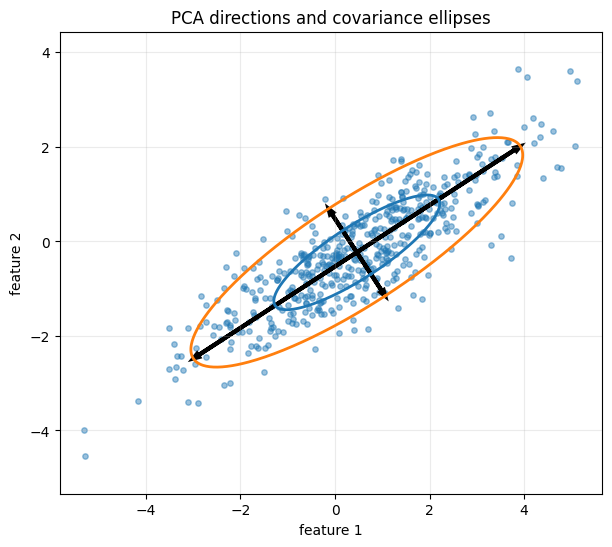

In [19]:
rng = np.random.default_rng(254)

mean_pca = np.array([0.5, -0.2])
Sigma_pca = np.array([[3.0, 1.8],
                      [1.8, 1.5]])
X_pca = rng.multivariate_normal(mean_pca, Sigma_pca, size=500)
X_centered = X_pca - X_pca.mean(axis=0)
C = X_centered.T @ X_centered / len(X_centered)

eigvals, eigvecs = np.linalg.eigh(C)
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

print("Sample covariance:")
print(C)
print("Eigenvalues:", eigvals)
print("Principal directions as columns:")
print(eigvecs)

plt.figure(figsize=(7, 6))
plt.scatter(X_pca[:,0], X_pca[:,1], s=15, alpha=0.45)
mu_pca = X_pca.mean(axis=0)
for j in range(2):
    v = eigvecs[:,j]
    scale = 2*np.sqrt(eigvals[j])
    plt.arrow(mu_pca[0], mu_pca[1], scale*v[0], scale*v[1],
              head_width=0.08, linewidth=3, length_includes_head=True)
    plt.arrow(mu_pca[0], mu_pca[1], -scale*v[0], -scale*v[1],
              head_width=0.08, linewidth=3, length_includes_head=True)
for level in [1, 2]:
    xe, ye = covariance_ellipse_points(mu_pca, C, level=level)
    plt.plot(xe, ye, linewidth=2)
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.title("PCA directions and covariance ellipses")
plt.axis("equal")
plt.grid(True, alpha=0.25)
plt.show()

## 16. Variance as a function of direction angle

Let

$$
u(\theta)=\langle\cos\theta,\sin\theta\rangle.
$$

Then

$$
V(\theta)=u(\theta)^TCu(\theta).
$$

The maximum occurs at the top principal direction.

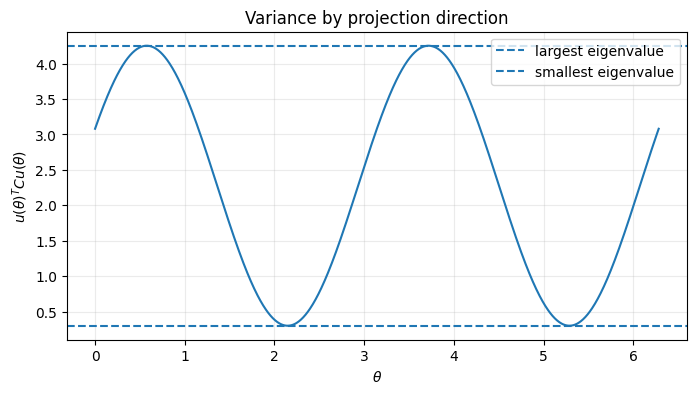

Maximizing direction from scan: [-0.838927 -0.544243]
Top eigenvector: [-0.838685 -0.544617]
Absolute dot product: 0.9999999005922743


In [20]:
theta = np.linspace(0, 2*np.pi, 1000)
U = np.column_stack([np.cos(theta), np.sin(theta)])
var_theta = np.einsum("ij,jk,ik->i", U, C, U)

theta_max = theta[np.argmax(var_theta)]
u_max = np.array([np.cos(theta_max), np.sin(theta_max)])

plt.figure(figsize=(8, 4))
plt.plot(theta, var_theta)
plt.axhline(eigvals[0], linestyle="--", label="largest eigenvalue")
plt.axhline(eigvals[1], linestyle="--", label="smallest eigenvalue")
plt.xlabel(r"$\theta$")
plt.ylabel(r"$u(\theta)^T C u(\theta)$")
plt.title("Variance by projection direction")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

print("Maximizing direction from scan:", u_max)
print("Top eigenvector:", eigvecs[:,0])
print("Absolute dot product:", abs(u_max @ eigvecs[:,0]))

---

# Part X. K-means as alternating minimization

K-means minimizes the within-cluster sum of squares:

$$
L(c_1,\ldots,c_K,z_1,\ldots,z_n)=
\sum_i\|x_i-c_{z_i}\|^2.
$$

The algorithm alternates:

1. assign each point to the nearest center;
2. update each center to the mean of its assigned points.

This is a form of coordinate descent on a nonconvex objective.

## 17. Implement K-means

Final centers:
[[ 0.96571   0.848716]
 [-1.724562 -1.517321]
 [-2.174307 -0.62758 ]]
Final K-means loss: 617.4643700444319


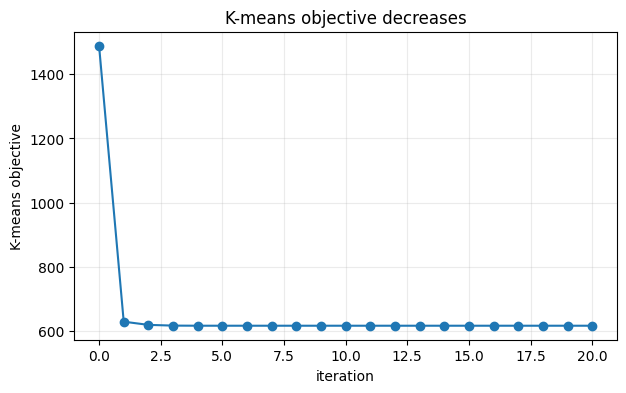

In [21]:
rng = np.random.default_rng(255)

centers_true = np.array([[-2, -1], [2, -0.5], [0, 2.2]])
X_km = np.vstack([
    rng.normal(loc=c, scale=0.55, size=(90, 2))
    for c in centers_true
])

def assign_clusters(X, centers):
    d2 = np.sum((X[:,None,:] - centers[None,:,:])**2, axis=2)
    return np.argmin(d2, axis=1), np.min(d2, axis=1)

def update_centers(X, labels, K):
    centers = np.zeros((K, X.shape[1]))
    for k in range(K):
        if np.any(labels == k):
            centers[k] = X[labels == k].mean(axis=0)
        else:
            centers[k] = X[np.random.randint(len(X))]
    return centers

def kmeans_loss(X, centers, labels):
    return float(np.sum((X - centers[labels])**2))

K = 3
init_idx = rng.choice(len(X_km), size=K, replace=False)
centers = X_km[init_idx].copy()

history_centers = [centers.copy()]
history_loss = []

for it in range(20):
    labels, d2min = assign_clusters(X_km, centers)
    history_loss.append(kmeans_loss(X_km, centers, labels))
    centers = update_centers(X_km, labels, K)
    history_centers.append(centers.copy())

labels, _ = assign_clusters(X_km, centers)
history_loss.append(kmeans_loss(X_km, centers, labels))
history_centers = np.array(history_centers)

print("Final centers:")
print(centers)
print("Final K-means loss:", history_loss[-1])

plt.figure(figsize=(7, 4))
plt.plot(history_loss, marker="o")
plt.xlabel("iteration")
plt.ylabel("K-means objective")
plt.title("K-means objective decreases")
plt.grid(True, alpha=0.25)
plt.show()

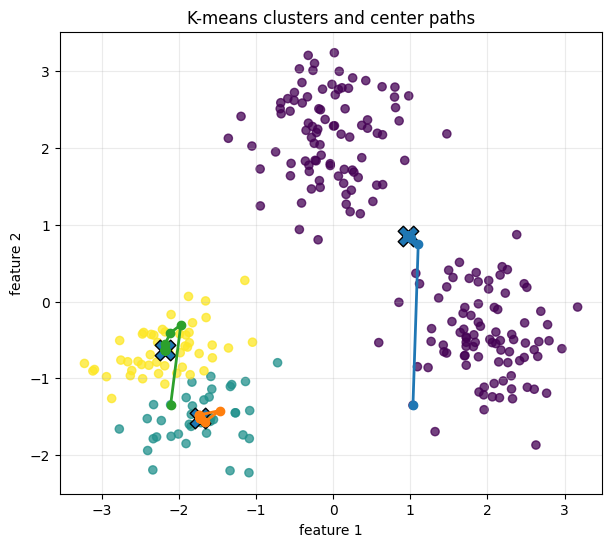

In [22]:
plt.figure(figsize=(7, 6))
plt.scatter(X_km[:,0], X_km[:,1], c=labels, s=35, alpha=0.75)
for k in range(K):
    plt.plot(history_centers[:,k,0], history_centers[:,k,1], marker="o", linewidth=2)
plt.scatter(centers[:,0], centers[:,1], s=220, marker="X", edgecolor="k")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.title("K-means clusters and center paths")
plt.axis("equal")
plt.grid(True, alpha=0.25)
plt.show()

---

# Part XI. A tiny neural network and the chain rule

A neural network is a composition of functions.  
For one hidden layer,

$$
\widehat y = W_2 \tanh(XW_1+b_1)+b_2.
$$

Training uses the chain rule to compute gradients by backpropagation.

## 18. Train a small neural network for nonlinear regression

Final neural network loss: 0.018363618856216103


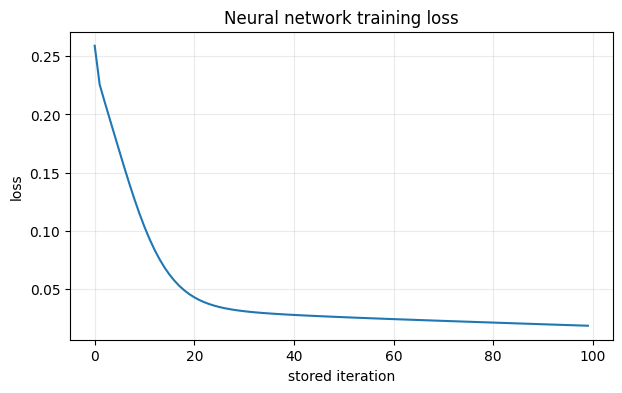

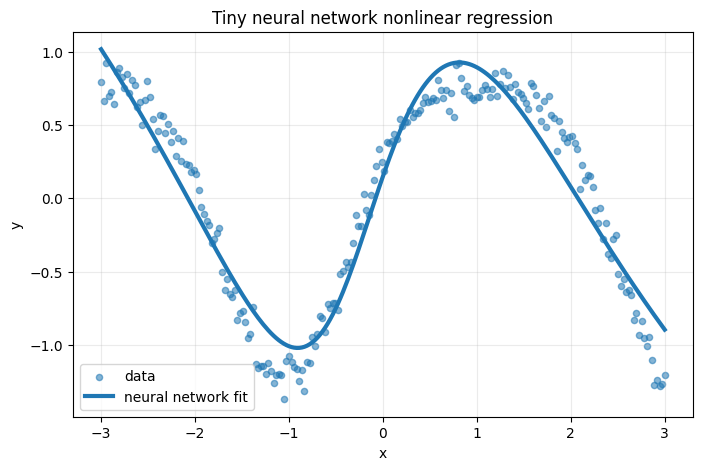

In [23]:
rng = np.random.default_rng(256)

n = 220
x_nn = np.linspace(-3, 3, n)[:,None]
y_nn = np.sin(1.5*x_nn[:,0]) + 0.25*np.cos(3*x_nn[:,0]) + rng.normal(scale=0.08, size=n)

hidden = 12
W1 = rng.normal(scale=0.4, size=(1, hidden))
b1 = np.zeros(hidden)
W2 = rng.normal(scale=0.3, size=(hidden, 1))
b2 = np.zeros(1)

def nn_forward(x, W1, b1, W2, b2):
    Z1 = x @ W1 + b1
    A1 = np.tanh(Z1)
    Yhat = A1 @ W2 + b2
    return Z1, A1, Yhat[:,0]

def nn_loss(W1, b1, W2, b2):
    _, _, pred = nn_forward(x_nn, W1, b1, W2, b2)
    return 0.5*np.mean((pred-y_nn)**2)

loss_history = []
lr = 0.04

for it in range(2500):
    Z1, A1, pred = nn_forward(x_nn, W1, b1, W2, b2)
    r = pred - y_nn
    loss = 0.5*np.mean(r**2)
    if it % 25 == 0:
        loss_history.append(loss)

    # Backpropagation
    dY = r[:,None]/n
    dW2 = A1.T @ dY
    db2 = np.sum(dY, axis=0)
    dA1 = dY @ W2.T
    dZ1 = dA1*(1 - np.tanh(Z1)**2)
    dW1 = x_nn.T @ dZ1
    db1 = np.sum(dZ1, axis=0)

    W1 -= lr*dW1
    b1 -= lr*db1
    W2 -= lr*dW2
    b2 -= lr*db2

_, _, pred_nn = nn_forward(x_nn, W1, b1, W2, b2)

print("Final neural network loss:", nn_loss(W1, b1, W2, b2))

plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.xlabel("stored iteration")
plt.ylabel("loss")
plt.title("Neural network training loss")
plt.grid(True, alpha=0.25)
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(x_nn[:,0], y_nn, s=20, alpha=0.55, label="data")
plt.plot(x_nn[:,0], pred_nn, linewidth=3, label="neural network fit")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Tiny neural network nonlinear regression")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

## 19. Gradient check for one neural-network parameter

Backpropagation is just the chain rule.  
We check one component of $W_1$ using finite differences.

In [24]:
# Pick one parameter W1[0,0].
i, j = 0, 0
eps = 1e-5

# Recompute analytic gradient at final parameters.
Z1, A1, pred = nn_forward(x_nn, W1, b1, W2, b2)
r = pred - y_nn
dY = r[:,None]/n
dA1 = dY @ W2.T
dZ1 = dA1*(1 - np.tanh(Z1)**2)
dW1 = x_nn.T @ dZ1

W1_plus = W1.copy()
W1_minus = W1.copy()
W1_plus[i,j] += eps
W1_minus[i,j] -= eps

loss_plus = nn_loss(W1_plus, b1, W2, b2)
loss_minus = nn_loss(W1_minus, b1, W2, b2)
finite_diff = (loss_plus - loss_minus)/(2*eps)

print("Backprop gradient W1[0,0]:", dW1[i,j])
print("Finite-difference gradient:", finite_diff)
print("Difference:", dW1[i,j] - finite_diff)

Backprop gradient W1[0,0]: 7.416523823305064e-05
Finite-difference gradient: 7.416527964682063e-05
Difference: -4.1413769982789894e-11


---

# Part XII. Chapter mini-project: end-to-end learning workflow

In this mini-project, we combine several ideas:

1. simulate a nonlinear binary classification data set;
2. create polynomial features;
3. train logistic regression by gradient descent;
4. use train/test split and standardization;
5. visualize the decision boundary;
6. interpret the model through gradients and loss curvature.

## 20. Simulate nonlinear classification data

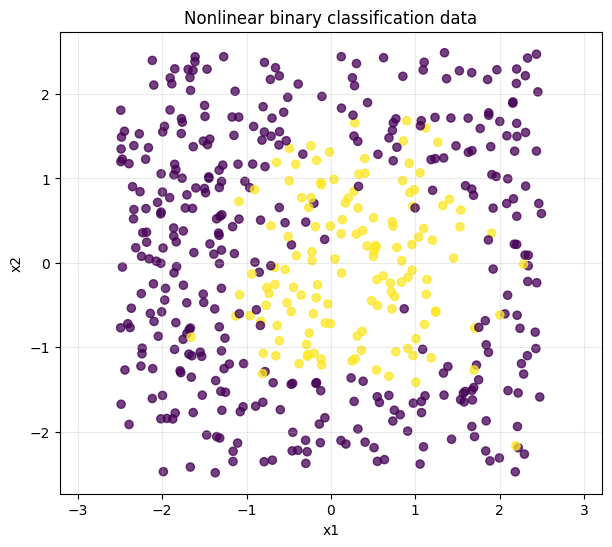

In [25]:
rng = np.random.default_rng(257)

n = 500
X_proj = rng.uniform(-2.5, 2.5, size=(n, 2))
radius2 = X_proj[:,0]**2 + X_proj[:,1]**2
signal = 2.0 - radius2 + 0.8*X_proj[:,0] - 0.5*np.sin(2*X_proj[:,1])
prob = sigmoid(1.7*signal)
y_proj = rng.binomial(1, prob)

plt.figure(figsize=(7, 6))
plt.scatter(X_proj[:,0], X_proj[:,1], c=y_proj, s=35, alpha=0.75)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Nonlinear binary classification data")
plt.axis("equal")
plt.grid(True, alpha=0.25)
plt.show()

## 21. Polynomial features and training

Train accuracy: 0.9013333333333333
Test accuracy: 0.936
Final loss: 0.25526989602740113
Gradient norm: 0.0008101375370825804
Hessian eigenvalues min/max: 0.006050802019508049 0.13366918371537065


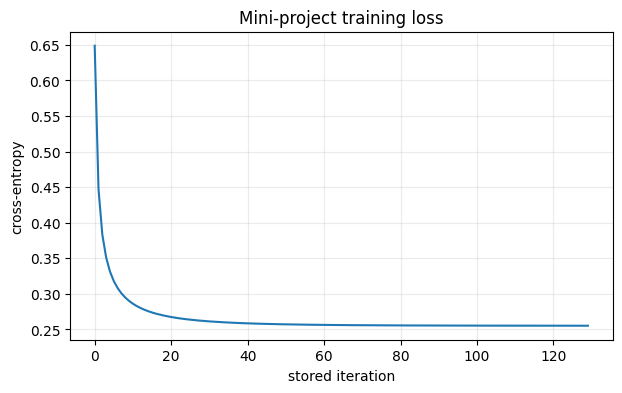

In [26]:
def polynomial_features_2d(X):
    x1 = X[:,0]
    x2 = X[:,1]
    return np.column_stack([
        x1,
        x2,
        x1**2,
        x1*x2,
        x2**2,
        np.sin(2*x2)
    ])

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_proj, y_proj, test_fraction=0.25, seed=258)

Phi_train = polynomial_features_2d(X_train_raw)
Phi_test = polynomial_features_2d(X_test_raw)
Phi_train_scaled, Phi_test_scaled, phi_mean, phi_std = standardize_train_test(Phi_train, Phi_test)

Xtr = add_intercept(Phi_train_scaled)
Xte = add_intercept(Phi_test_scaled)

def proj_loss(beta):
    eta = Xtr @ beta
    return float(np.mean(np.logaddexp(0, eta) - y_train*eta))

def proj_grad(beta):
    p = sigmoid(Xtr @ beta)
    return Xtr.T @ (p-y_train)/len(y_train)

def proj_hess(beta):
    p = sigmoid(Xtr @ beta)
    w = p*(1-p)
    return Xtr.T @ (Xtr*w[:,None])/len(y_train)

beta_proj = np.zeros(Xtr.shape[1])
loss_proj_hist = []

for it in range(1300):
    beta_proj = beta_proj - 0.35*proj_grad(beta_proj)
    if it % 10 == 0:
        loss_proj_hist.append(proj_loss(beta_proj))

p_train = sigmoid(Xtr @ beta_proj)
p_test = sigmoid(Xte @ beta_proj)
train_pred = (p_train >= 0.5).astype(int)
test_pred = (p_test >= 0.5).astype(int)

print("Train accuracy:", accuracy(y_train, train_pred))
print("Test accuracy:", accuracy(y_test, test_pred))
print("Final loss:", proj_loss(beta_proj))
print("Gradient norm:", norm(proj_grad(beta_proj)))
print("Hessian eigenvalues min/max:", np.linalg.eigvalsh(proj_hess(beta_proj))[0], np.linalg.eigvalsh(proj_hess(beta_proj))[-1])

plt.figure(figsize=(7, 4))
plt.plot(loss_proj_hist)
plt.xlabel("stored iteration")
plt.ylabel("cross-entropy")
plt.title("Mini-project training loss")
plt.grid(True, alpha=0.25)
plt.show()

## 22. Decision boundary for the nonlinear classifier

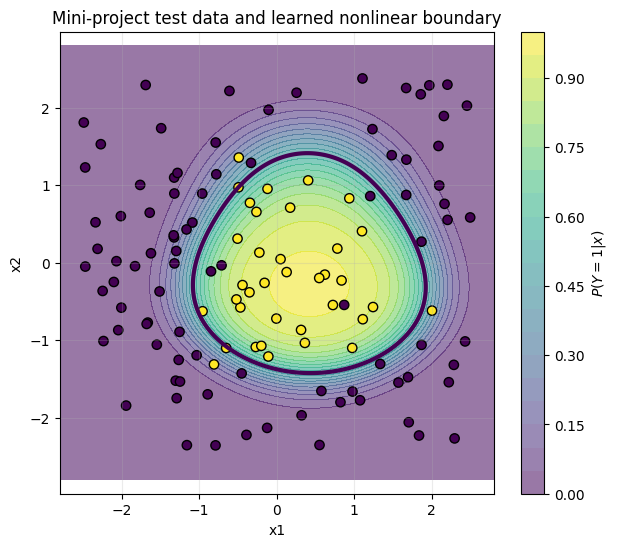

In [27]:
xx = np.linspace(-2.8, 2.8, 350)
yy = np.linspace(-2.8, 2.8, 350)
XX, YY = np.meshgrid(xx, yy)
Grid_raw = np.column_stack([XX.ravel(), YY.ravel()])
Grid_features = polynomial_features_2d(Grid_raw)
Grid_features_scaled = (Grid_features - phi_mean)/phi_std
Grid_design = add_intercept(Grid_features_scaled)
Grid_prob = sigmoid(Grid_design @ beta_proj).reshape(XX.shape)

plt.figure(figsize=(7, 6))
plt.contourf(XX, YY, Grid_prob, levels=20, alpha=0.55)
plt.colorbar(label=r"$P(Y=1|x)$")
plt.contour(XX, YY, Grid_prob, levels=[0.5], linewidths=3)
plt.scatter(X_test_raw[:,0], X_test_raw[:,1], c=y_test, s=45, edgecolor="k")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Mini-project test data and learned nonlinear boundary")
plt.axis("equal")
plt.grid(True, alpha=0.25)
plt.show()

## 23. Mini-project questions

Answer the following in a markdown cell:

1. Which polynomial features made the decision boundary nonlinear?
2. Why was feature standardization important for gradient descent?
3. What does the gradient norm tell you at the final iteration?
4. What does the Hessian reveal about local curvature?
5. How do train and test accuracy compare?
6. How might regularization improve this workflow?

In [28]:
print("Mini-project summary")
print("--------------------")
print("Number of training examples:", len(y_train))
print("Number of test examples:", len(y_test))
print("Number of parameters:", len(beta_proj))
print("Train accuracy:", accuracy(y_train, train_pred))
print("Test accuracy:", accuracy(y_test, test_pred))
print("Final gradient norm:", norm(proj_grad(beta_proj)))
print("Final parameter vector:")
print(beta_proj)

Mini-project summary
--------------------
Number of training examples: 375
Number of test examples: 125
Number of parameters: 7
Train accuracy: 0.9013333333333333
Test accuracy: 0.936
Final gradient norm: 0.0008101375370825804
Final parameter vector:
[-3.31988   1.782974  0.18534  -2.737591 -0.081299 -2.686279 -0.454872]


---

# Part XIII. Additional exercises with reference solutions

Try each exercise before running the reference solution.

## Exercise A. Gradient of least squares

For

$$
L(\theta)=\frac{1}{2n}\|X\theta-y\|^2,
$$

verify numerically that

$$
\nabla L(\theta)=\frac1nX^T(X\theta-y)
$$

for a random parameter vector.

In [29]:
# Exercise A workspace

# Your code here

### Reference solution for Exercise A

In [30]:
theta_test = np.array([0.3, -0.5, 0.8])
grad_formula = lin_grad(theta_test)
grad_numeric = finite_gradient(lin_loss, theta_test)

print("Formula gradient:", grad_formula)
print("Numerical gradient:", grad_numeric)
print("Difference:", grad_formula - grad_numeric)

Formula gradient: [-1.117187 -2.504407  2.21355 ]
Numerical gradient: [-1.117187 -2.504407  2.21355 ]
Difference: [-0. -0. -0.]


## Exercise B. Ridge regression

Compute the ridge solution for $\lambda=0.5$ and compare with the least-squares solution.

In [31]:
# Exercise B workspace

# Your code here

### Reference solution for Exercise B

In [32]:
theta_ridge_05 = ridge_solution(X_design, y, 0.5)
print("Least-squares:", theta_lstsq)
print("Ridge lambda=0.5:", theta_ridge_05)
print("Coefficient norms:")
print("LS non-intercept norm:", norm(theta_lstsq[1:]))
print("Ridge non-intercept norm:", norm(theta_ridge_05[1:]))

Least-squares: [ 1.204936  2.019457 -1.418413]
Ridge lambda=0.5: [ 1.260762  1.331668 -0.939679]
Coefficient norms:
LS non-intercept norm: 2.467813601362496
Ridge non-intercept norm: 1.6298271852006114


## Exercise C. Logistic Hessian

Show numerically that the logistic-regression Hessian is positive semidefinite at the fitted parameter.

In [33]:
# Exercise C workspace

# Your code here

### Reference solution for Exercise C

In [34]:
H_log = log_hess(beta_log_hat)
eig_log = np.linalg.eigvalsh(H_log)

print("Logistic Hessian eigenvalues:", eig_log)
print("Positive semidefinite?", np.all(eig_log >= -1e-10))

Logistic Hessian eigenvalues: [0.049754 0.137672 0.141075]
Positive semidefinite? True


## Exercise D. PCA projection

Project the PCA data onto the first principal component and compute the sample variance of the projected coordinates.

In [35]:
# Exercise D workspace

# Your code here

### Reference solution for Exercise D

In [36]:
pc1 = eigvecs[:,0]
scores1 = X_centered @ pc1
var_scores1 = np.mean(scores1**2)

print("Variance of first PC scores:", var_scores1)
print("Largest covariance eigenvalue:", eigvals[0])

Variance of first PC scores: 4.251563950132767
Largest covariance eigenvalue: 4.251563950132765


## Exercise E. K-means objective

Run K-means with a different random initialization. Does it end with the same objective?

In [37]:
# Exercise E workspace

# Your code here

### Reference solution for Exercise E

Original final objective: 617.4643700444319
New final objective: 149.1535252021751


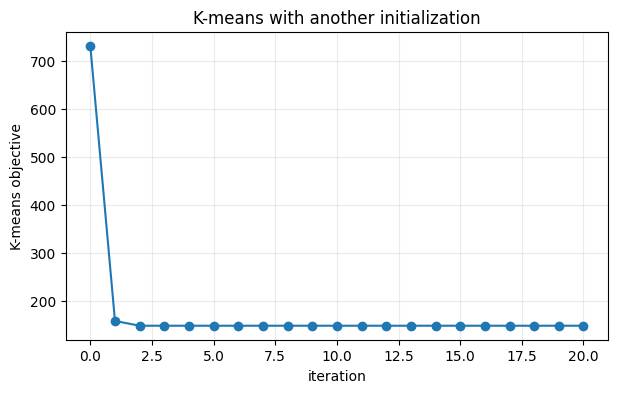

In [38]:
rng2 = np.random.default_rng(999)
centers2 = X_km[rng2.choice(len(X_km), size=K, replace=False)].copy()
loss2 = []

for it in range(20):
    labels2, _ = assign_clusters(X_km, centers2)
    loss2.append(kmeans_loss(X_km, centers2, labels2))
    centers2 = update_centers(X_km, labels2, K)

labels2, _ = assign_clusters(X_km, centers2)
loss2.append(kmeans_loss(X_km, centers2, labels2))

print("Original final objective:", history_loss[-1])
print("New final objective:", loss2[-1])

plt.figure(figsize=(7, 4))
plt.plot(loss2, marker="o")
plt.xlabel("iteration")
plt.ylabel("K-means objective")
plt.title("K-means with another initialization")
plt.grid(True, alpha=0.25)
plt.show()

---

# Formula summary

## Least-squares loss

$$
L(\theta)=\frac{1}{2n}\|X\theta-y\|^2.
$$

## Least-squares gradient and Hessian

$$
\nabla L(\theta)=\frac1nX^T(X\theta-y),
\qquad
H=\frac1nX^TX.
$$

## Gradient descent

$$
\theta_{k+1}=\theta_k-\eta\nabla L(\theta_k).
$$

## Newton step

$$
\theta_{k+1}=\theta_k-H^{-1}\nabla L(\theta_k).
$$

## Ridge loss

$$
L_\lambda(\theta)=
\frac{1}{2n}\|X\theta-y\|^2+
\frac{\lambda}{2}\|\theta_{1:p}\|^2.
$$

## Logistic sigmoid

$$
\sigma(z)=\frac1{1+e^{-z}}.
$$

## Logistic cross-entropy

$$
L(\beta)=
\frac1n\sum_i
\left[
\log(1+e^{x_i^T\beta})-y_i x_i^T\beta
\right].
$$

## Softmax

$$
p_k=\frac{e^{s_k}}{\sum_{\ell=1}^K e^{s_\ell}}.
$$

## Jacobian chain rule

If $L(x)=g(\phi(x))$, then

$$
\nabla_xL=J_\phi(x)^T\nabla_zg.
$$

## PCA variance objective

$$
\max_{\|u\|=1}u^TCu.
$$

The maximizer is the top eigenvector of $C$.

## K-means objective

$$
\sum_i\|x_i-c_{z_i}\|^2.
$$

## One-hidden-layer neural network

$$
\widehat y=W_2\tanh(XW_1+b_1)+b_2.
$$

# End of Chapter 25 Lab

You have used Python to explore:

- data and parameter spaces,
- least-squares loss landscapes,
- gradients, Hessians, and Newton steps,
- gradient descent and step-size stability,
- feature scaling and conditioning,
- ridge regularization,
- logistic regression and cross-entropy,
- softmax classification,
- Jacobians and feature maps,
- PCA and quadratic variance maximization,
- K-means as alternating minimization,
- a tiny neural network trained by backpropagation,
- and an end-to-end nonlinear classification mini-project.

These ideas show how multivariable calculus supports the core geometry and algorithms of data science and machine learning.